<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/Univariate_Temperature_RNN.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 6 — Univariate RNN Pt 1: the 3-D tensor and split_sequence
- Drop the window feature engineering - hand the RNN the raw sequence as a 3-D tensor and let it learn the temporal features (like the ConvNet learned image features).
- 3,650 daily temperatures, look-back 10 -> 3,640 samples of 10 x 1. split_sequence: [1,2,3] -> 4, [2,3,4] -> 5, oldest to newest.
- The reshape to add the trailing 1 is where 90% of RNN errors live - do it slowly on camera.
- Chronological 90/10: 3,276 train / 364 test.
-->


# Univariate Temperature Example (RNN), Part 1: Fit and Beat the Baselines
-------------------------

**Dr. Dave Wanik - University of Connecticut**

Can we predict **tomorrow's minimum temperature** from the previous 10 days?

This is a **many-to-one regression**: a sequence of 10 values goes in, one number comes out. We'll hand the raw sequence to a SimpleRNN, then an LSTM, and then ask the only question that matters: **did either one beat the dumb models?** The dumb models are the mean, yesterday's value, and the window method you already built (a plain dense net on the same 10 days).

**Part 2** (`Univariate_Temperature_RNN_pt2`) picks up the saved model: it reloads it, asks what the model is looking at with **occlusion by lag**, and then rolls its own predictions forward two weeks.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping

# reproducibility: same seed every run (numbers on CPU match exactly; a GPU may drift a little)
import keras
keras.utils.set_random_seed(5509)


## Read in data
Check for missing values, make some plots.

In [2]:
# Dataset initially sourced from jbrownlee’s GitHub repository:
# url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
# Link to the data file on Github
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/refs/heads/main/OPIM5509_Module4_Files/data/daily-min-temperatures.csv"

# read the data
df = pd.read_csv(url)
print(df.info())
df.head(n=15) # nice complete data! this will allow us to check our work later

<class 'pandas.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3650 non-null   str    
 1   Temp    3650 non-null   float64
dtypes: float64(1), str(1)
memory usage: 92.8 KB
None


,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8
5,1981-01-06,15.8
6,1981-01-07,15.8
7,1981-01-08,17.4
8,1981-01-09,21.8
9,1981-01-10,20.0


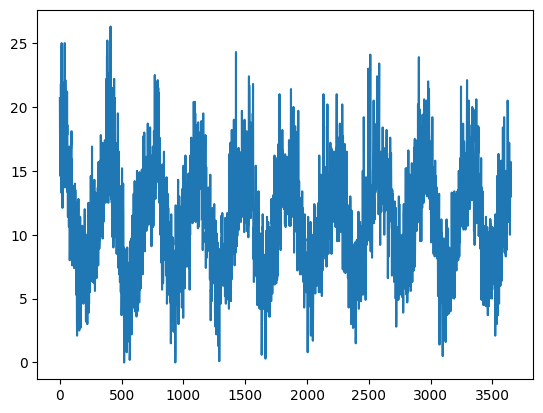

In [3]:
# visualize the data
df['Temp'].plot()
plt.show()

<!-- WINDOW-FN -->
## The window-making function: `split_sequence`

Chops **one column** into overlapping windows.

- **`n_steps`** is the **look-back**: each input X is `n_steps` values in a row.
- The target y is the **next** value after the window.

With `[10, 20, 30, 40, 50]` and `n_steps=3`: `[10, 20, 30] → 40`, then `[20, 30, 40] → 50`. The result is `(samples, n_steps)`, and we add a trailing `1` for Keras: `(samples, n_steps, 1)`.


In [4]:
# prep data for modeling (univariate)
# link: https://machinelearningmastery.com/how-to-develop-lstm-models-for-time-series-forecasting/

# univariate data preparation
from numpy import array

# split a univariate sequence into samples
def split_sequence(sequence, n_steps):
	X, y = list(), list()
	for i in range(len(sequence)):
		# find the end of this pattern
		end_ix = i + n_steps
		# check if we are beyond the sequence
		if end_ix > len(sequence)-1:
			break
		# gather input and output parts of the pattern
		seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
		X.append(seq_x)
		y.append(seq_y)
	return array(X), array(y)

In [5]:
# here's an example of how this script works
# define input sequence
raw_seq = [10, 20, 30, 40, 50, 60, 70, 80, 90]
# choose a number of time steps
n_steps = 3
# split into samples
X, y = split_sequence(raw_seq, n_steps)
# summarize the data
for i in range(len(X)):
	print(X[i], y[i])

[10 20 30] 40
[20 30 40] 50
[30 40 50] 60
[40 50 60] 70
[50 60 70] 80
[60 70 80] 90


In [6]:
# all we need to do is decide on is n_steps (what our lookback period is)
# since we have a bunch of data, why not n_steps=10? then try 30 later on.
n_steps = 10
raw_seq = df['Temp'] # the second column, where the data is. UPDATE THIS ON YOUR DATA!
# let's ignore the date column and just use the temperature data
X, y = split_sequence(raw_seq, n_steps)

In [7]:
# check out X and y shape
print(df.shape)
print(X.shape)

(3650, 2)
(3640, 10)


In [8]:
# take a peek at what it did
print(X[0])
print(y[0])

# scroll up and make sure you understand this!
# y is a function of X (the previous n_steps observations!)

[20.7 17.9 18.8 14.6 15.8 15.8 15.8 17.4 21.8 20. ]
16.2


In [9]:
# now we reshape the data into a 3D array
# reshape from [samples, timesteps] into [samples, timesteps, features]
n_features = 1 # this is 1 because it is univariate data
X = X.reshape((X.shape[0], X.shape[1], n_features))
X.shape

(3640, 10, 1)

In [10]:
# split the data into train and test partitions
# we will use 90% of the data for train, and 10% for validation
train_pct_index = int(0.9 * len(X))
X_train, X_test = X[:train_pct_index], X[train_pct_index:]
y_train, y_test = y[:train_pct_index], y[train_pct_index:]

# pretty slick way of splitting your data using slicing!
# notice how we didn't do any shuffling (we don't want temporal leakage! keeps time series intact)

In [11]:
# check the shape to be sure
print(X.shape, X_train.shape, X_test.shape)

# verify that this all adds up!

(3640, 10, 1) (3276, 10, 1) (364, 10, 1)


In [12]:
# peek at it!
X_train[0]

array([[20.7],
       [17.9],
       [18.8],
       [14.6],
       [15.8],
       [15.8],
       [15.8],
       [17.4],
       [21.8],
       [20. ]])

In [13]:
y[0]

np.float64(16.2)

In [14]:
# if we wanted to, we could do some scaling/normalization here, would not hurt!

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 7 — Univariate RNN Pt 2: fit SimpleRNN, then LSTM, then beat the baselines
- Confirm the tensor (3640, 10, 1); inherit n_steps and n_features FROM THE SHAPE; 30 red dots -> 31x30+30 = 960 + 31 = 991 params, spinning 10 times.
- show_results() gives every model the same three checks: MAE, actual-vs-predicted scatter, predictions over time. Never trust one plot.
- SimpleRNN 1.78 C, then the one-word swap to LSTM (3,871 params) 1.76 C.
- The sermon: three dumb models on the same 364 days - mean-only, persistence (yesterday), and the WINDOW METHOD rebuilt on these exact windows (flatten (3276,10,1) to (3276,10)).
- Scoreboard: LSTM 1.76, SimpleRNN 1.78, window method 1.80, persistence 2.02, mean-only 3.23. The recurrent models crush mean-only and persistence but beat the window method by only 2.3% - 10 days of one number is an easy problem. RNNs earn their keep on long look-backs, many features, multi-step (the rest of M4).
-->


## One helper to score every model the same way

Every model in this notebook gets the **same three checks**: the MAE, a scatter of actual vs predicted (points on the red line are perfect), and the predictions over time. A model that just repeats yesterday can look great on the time-series plot, so we never look at one plot alone.


In [15]:
scores = {}

def show_results(name, pred_test, pred_train=None):
    """Score a model on TEST and, when train predictions are passed, on TRAIN too.
    Left: actual vs predicted (the red 45-degree line is perfection). Right: the same days as a time series."""
    pred_test = np.asarray(pred_test).ravel()
    mae_test = mean_absolute_error(y_test, pred_test)
    scores[name] = mae_test

    rows = [("test", y_test, pred_test)]
    if pred_train is not None:
        pred_train = np.asarray(pred_train).ravel()
        mae_train = mean_absolute_error(y_train, pred_train)
        rows.insert(0, ("train", y_train, pred_train))
        print(f"{name}:  train MAE = {mae_train:.2f} C   test MAE = {mae_test:.2f} C"
              f"   (gap {mae_test - mae_train:+.2f} C)")
    else:
        print(f"{name}: test MAE = {mae_test:.2f} C")

    fig, ax = plt.subplots(len(rows), 2, figsize=(12, 3.4 * len(rows)),
                           gridspec_kw={"width_ratios": [1, 2]}, squeeze=False)
    for r, (split, y_true, pred) in enumerate(rows):
        ax[r][0].scatter(y_true, pred, s=8, alpha=0.5)
        ax[r][0].plot([0, 26], [0, 26], color="red")            # the 45-degree line: perfect predictions
        ax[r][0].set_xlabel("actual"); ax[r][0].set_ylabel("predicted")
        ax[r][0].set_title(f"{name} - {split}")
        ax[r][1].plot(y_true, color="blue", lw=1, label="actual")
        ax[r][1].plot(pred, color="red", lw=1, alpha=0.8, label="predicted")
        ax[r][1].set_ylabel("min temp (C)"); ax[r][1].legend(loc="upper left")
    ax[-1][1].set_xlabel(f"{rows[-1][0]} day")
    plt.tight_layout(); plt.show()

# RNN one layer model

In [16]:
# samples, lookback, features
# samples = original rows in df - lookback period
# 3640 = 3650 - 10
X.shape

(3640, 10, 1)

In [17]:
# store these features for modeling
n_features = X.shape[2]
n_steps = X.shape[1]

print(n_steps, n_features)

10 1


In [ ]:

# now let's build a model

# since this is a univariate problem, n_features will be 1 (we also defined this before, but this is a better way)
n_features = X.shape[2] # 1 green dot
n_steps = X.shape[1] # 10 steps (not shown in the animation - this is how many times it loops)

# define model
model = Sequential()
model.add(Input(shape=(n_steps,n_features)))
model.add(SimpleRNN(30, activation='relu')) # 30 red dots
model.add(Dense(1, activation='linear'))
model.compile(optimizer='adam', loss='mse',metrics=['mae'])
model.summary()

es = EarlyStopping(monitor='val_loss', mode='min',
                   patience=10,
                   verbose=1,
                   restore_best_weights=True)

# fit model (uses early stopping)
history = model.fit(X_train, y_train,
          epochs=500,
          batch_size=5,
          validation_split=0.2, # val is a random 20% of the train data since we set shuffle = True
          verbose=1,
          callbacks=[es],
          shuffle=True)

## The loss curve

`fit()` hands back a **History** object, so always catch it: `history = model.fit(...)`. It holds the training loss and, because we passed `validation_split`, the validation loss at every epoch.

You will hear this called a *learning curve* too. In deep learning the two names get used for the same picture, but they are not the same thing in classical ML, where a **learning curve** plots performance against **training-set size**. What we are plotting is loss against **epoch**, so *loss curve* is the exact name.

Read it the usual way: both curves falling and flattening together is a healthy fit; the validation curve turning back up while the training curve keeps dropping is overfitting - which is exactly what `EarlyStopping` is watching for, and why `restore_best_weights=True` hands you the model from the bottom of that curve rather than the last epoch.

In [ ]:
# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 3))
plt.plot(history.history["loss"], label="train")
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("SimpleRNN(30): loss curve")
plt.legend(); plt.tight_layout(); plt.show()

print(f"stopped after {len(history.history['loss'])} epochs;"
      f" best validation loss {min(history.history['val_loss']):.3f}")

SimpleRNN(30): test MAE = 1.78 C


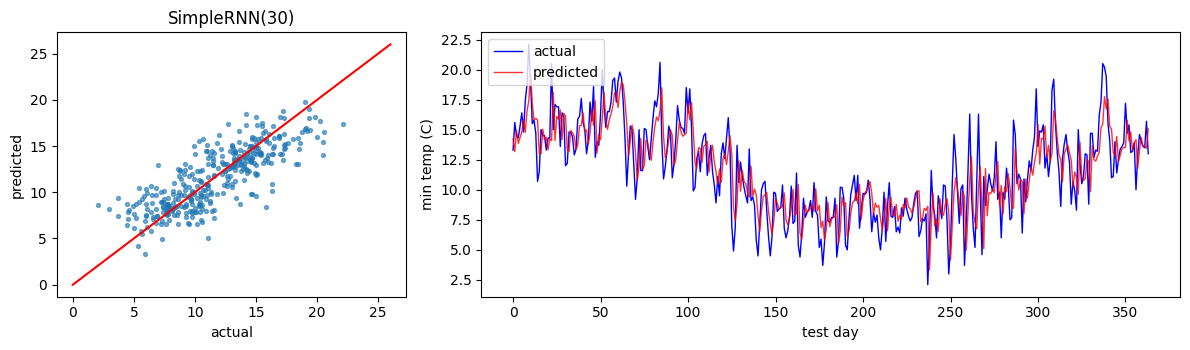

In [19]:
pred_rnn = model.predict(X_test, verbose=0)
show_results("SimpleRNN(30)", pred_rnn, model.predict(X_train, verbose=0))


# LSTM one layer model
Literally, just grab the code above and change SimpleRNN to LSTM and boom! you have a more sophisticated model.

In [ ]:
# now let's build a model

# since this is a univariate problem, n_features will be 1 (we also defined this before)
n_features = X.shape[2] # 1 green dot = 1 feature
n_steps = X.shape[1] # these are time steps = there are 10!

# define model
model = Sequential()
model.add(Input(shape=(n_steps,n_features)))
model.add(LSTM(30, activation='relu')) # 30 red dots = hidden size of 30
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse',metrics=['mae'])
model.summary()

es = EarlyStopping(monitor='val_loss', mode='min',
                   patience=10,
                   verbose=1,
                   restore_best_weights=True)

# fit model (uses early stopping)
history = model.fit(X_train, y_train,
          epochs=500,
          batch_size=5,
          validation_split=0.2, # val is a random 20% of the data since we set shuffle = True
          verbose=1,
          callbacks=[es],
          shuffle=True)

### Loss curve

In [ ]:
# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 3))
plt.plot(history.history["loss"], label="train")
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("LSTM(30): loss curve")
plt.legend(); plt.tight_layout(); plt.show()

print(f"stopped after {len(history.history['loss'])} epochs;"
      f" best validation loss {min(history.history['val_loss']):.3f}")

LSTM(30): test MAE = 1.76 C


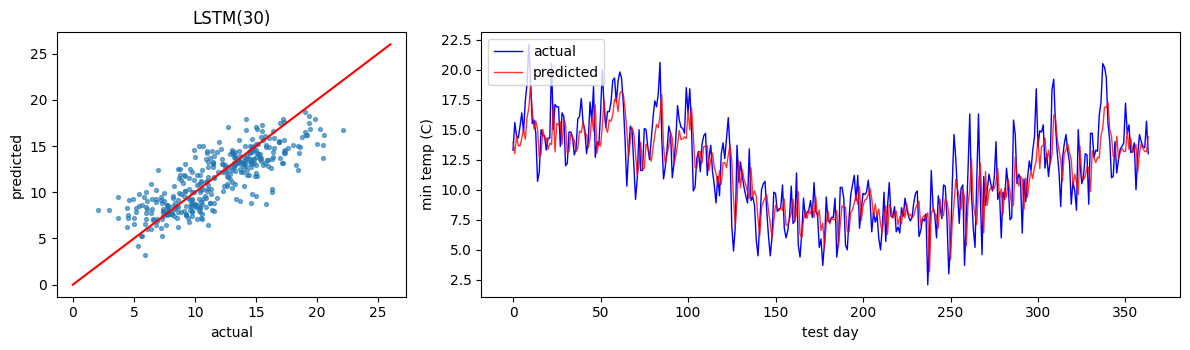

In [21]:
pred_lstm = model.predict(X_test, verbose=0)
show_results("LSTM(30)", pred_lstm, model.predict(X_train, verbose=0))


## Save the model and use it again

Reproducibility means more than a seed: **save the fitted model** so you (or a teammate, or your future self) can reload it and predict without retraining. Keras 3 saves to a single `.keras` file. The reloaded model must give *identical* predictions - we check.

In [22]:
from keras.models import load_model

model.save('Univariate_Temperature_RNN.keras')                 # one file: architecture + weights + optimizer state
reloaded = load_model('Univariate_Temperature_RNN.keras')

# same inputs, same answers?
import numpy as np
same = np.allclose(model.predict(X_test[:5], verbose=0), reloaded.predict(X_test[:5], verbose=0))
print('reloaded model reproduces the predictions:', same)
reloaded.summary()

reloaded model reproduces the predictions: True


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30)             │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,615 (45.38 KB)

 Trainable params: 3,871 (15.12 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,744 (30.25 KB)

# Did we beat the dumb models?

An RNN is only worth its parameters if it beats the things you could have done in one line. Three baselines, scored **on the same 364 test days** with the same helper:

1. **Mean-only**: predict the training-set average every day.
2. **Persistence**: tomorrow will be the same as today. Tough to beat on weather.
3. **The window method**: the same 10 days, flattened into 10 columns, into a plain dense net. This is the lags notebook, rebuilt on these exact windows. If the RNN can't beat it, the recurrent machinery bought us nothing.


### Baseline 1: mean-only

Predict the training-set average every single day. If a model can't beat this, it has learned nothing at all.

mean-only: test MAE = 3.23 C


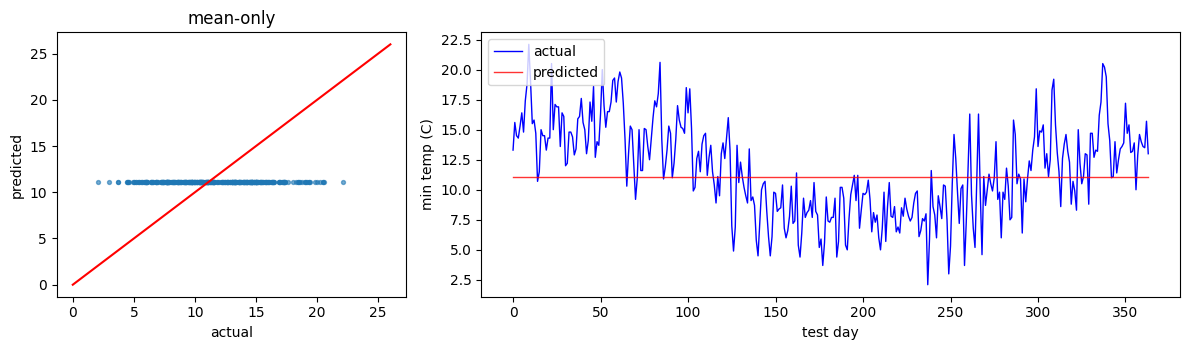

In [23]:
# baseline 1: mean-only
show_results("mean-only", np.full(len(y_test), y_train.mean()), np.full(len(y_train), y_train.mean()))


### Baseline 2: persistence (yesterday)

Tomorrow will be the same as today. Tough to beat on weather, and the one your students will underestimate.

persistence (yesterday): test MAE = 2.02 C


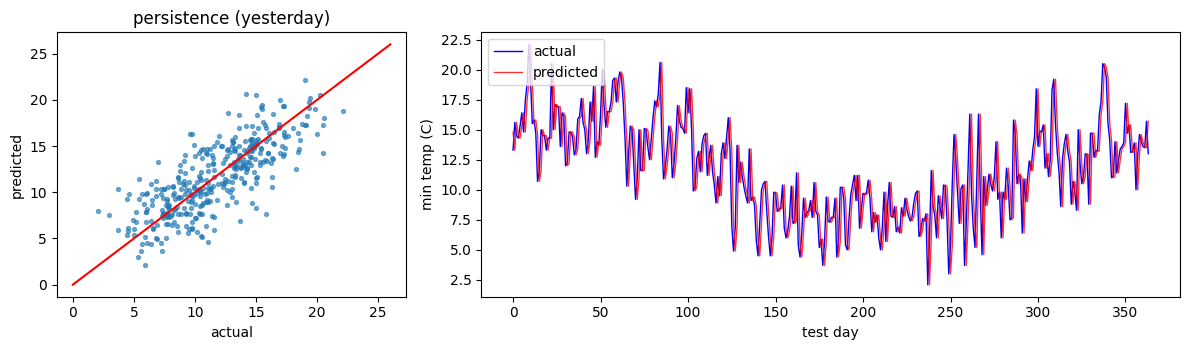

In [24]:
# baseline 2: persistence - the last value in each window IS yesterday
# (same numbers as df['Temp'].shift(1) lined up with the test days)
pred_persistence = X_test[:, -1, 0]
show_results("persistence (yesterday)", pred_persistence, X_train[:, -1, 0])


## Baseline 3: the window method

`X_train` is `(3276, 10, 1)`. Drop the trailing 1 and it's a table: 3,276 rows, 10 columns (day -10 ... day -1). A dense net can't see order, only columns. Same architecture as the lags notebook.


In [ ]:
X_train_flat = X_train.reshape(len(X_train), n_steps)   # (3276, 10): one column per past day
X_test_flat  = X_test.reshape(len(X_test), n_steps)

window_model = Sequential()
window_model.add(Input(shape=(n_steps,)))
window_model.add(Dense(30, activation="relu"))
window_model.add(Dense(1, activation="linear"))
window_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
window_model.summary()

es = EarlyStopping(monitor="val_loss", mode="min", patience=5, verbose=1, restore_best_weights=True)
window_history = window_model.fit(X_train_flat, y_train, epochs=500, batch_size=10, validation_split=0.2,
                 verbose=0, callbacks=[es], shuffle=True)

### Loss curve

In [ ]:
# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 3))
plt.plot(window_history.history["loss"], label="train")
if "val_loss" in window_history.history:
    plt.plot(window_history.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("Window method (dense net on 10 lags): loss curve")
plt.legend(); plt.tight_layout(); plt.show()

print(f"stopped after {len(window_history.history['loss'])} epochs;"
      f" best validation loss {min(window_history.history['val_loss']):.3f}")

In [ ]:
show_results("window method (dense net on 10 lags)", window_model.predict(X_test_flat, verbose=0),
             window_model.predict(X_train_flat, verbose=0))

## The scoreboard

LSTM(30)                                1.76
SimpleRNN(30)                           1.78
window method (dense net on 10 lags)    1.80
persistence (yesterday)                 2.02
mean-only                               3.23


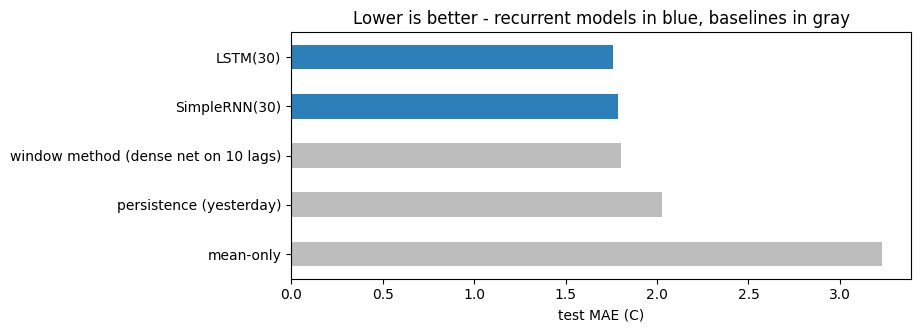


best recurrent model beats the best baseline by 2.3%


In [26]:
board = pd.Series(scores, name="test MAE (C)").sort_values()
print(board.round(2).to_string())

colors = ["#2c7fb8" if ("RNN" in k or "LSTM" in k) else "#bdbdbd" for k in board.index]
board.plot(kind="barh", color=colors, figsize=(8, 3.2), title="Lower is better - recurrent models in blue, baselines in gray")
plt.xlabel("test MAE (C)"); plt.gca().invert_yaxis(); plt.show()

best_base = board.drop([k for k in board.index if "RNN" in k or "LSTM" in k]).min()
print(f"\nbest recurrent model beats the best baseline by {100 * (1 - board.min() / best_base):.1f}%")


**How to read this.** The RNN and LSTM should clearly beat mean-only and persistence. Against the window method they will be close, because 10 days of one number is a small, easy problem and a dense net on lags is a strong model. That's the honest lesson: recurrent layers earn their keep on **longer look-backs, many features, and multi-step forecasts**, which is where the rest of Module 4 goes.

**On your own:** re-run with `n_steps = 30`. Which model gains the most from the longer window?
